In [1]:
# RUN FIRST (Fix A): define a V2 sampler that always works (statevector, no shots)
from qiskit.primitives import StatevectorSampler

sampler = StatevectorSampler()

# Optional: quick sanity print
print("Sampler:", type(sampler))

Sampler: <class 'qiskit.primitives.statevector_sampler.StatevectorSampler'>


In [2]:
import matplotlib.pyplot as plt

%matplotlib inline
import numpy as np
from qiskit import QuantumCircuit
from qiskit_algorithms import EstimationProblem, IterativeAmplitudeEstimation
from qiskit_finance.circuit.library import NormalDistribution

In [3]:
# can be used in case a principal component analysis has been done to derive the uncertainty model, ignored in this example.
A = np.eye(2)
b = np.zeros(2)

# specify the number of qubits that are used to represent the different dimenions of the uncertainty model
num_qubits = [2, 2]

# specify the lower and upper bounds for the different dimension
low = [0, 0]
high = [0.12, 0.24]
mu = [0.12, 0.24]
sigma = 0.01 * np.eye(2)

# construct corresponding distribution
bounds = list(zip(low, high))
u = NormalDistribution(num_qubits, mu, sigma, bounds)

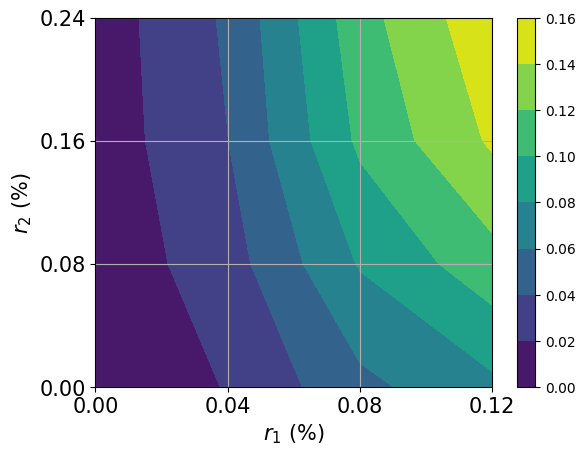

In [4]:
# plot contour of probability density function
x = np.linspace(low[0], high[0], 2 ** num_qubits[0])
y = np.linspace(low[1], high[1], 2 ** num_qubits[1])
z = u.probabilities.reshape(2 ** num_qubits[0], 2 ** num_qubits[1])
plt.contourf(x, y, z)
plt.xticks(x, size=15)
plt.yticks(y, size=15)
plt.grid()
plt.xlabel("$r_1$ (%)", size=15)
plt.ylabel("$r_2$ (%)", size=15)
plt.colorbar()
plt.show()

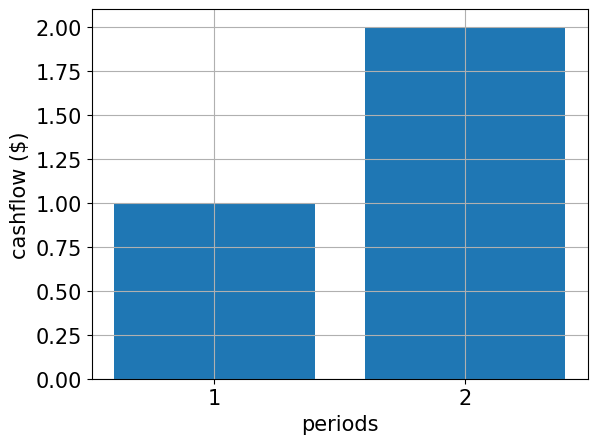

In [5]:
# specify cash flow
cf = [1.0, 2.0]
periods = range(1, len(cf) + 1)

# plot cash flow
plt.bar(periods, cf)
plt.xticks(periods, size=15)
plt.yticks(size=15)
plt.grid()
plt.xlabel("periods", size=15)
plt.ylabel("cashflow ($)", size=15)
plt.show()

In [6]:
# estimate real value
cnt = 0
exact_value = 0.0
for x1 in np.linspace(low[0], high[0], pow(2, num_qubits[0])):
    for x2 in np.linspace(low[1], high[1], pow(2, num_qubits[1])):
        prob = u.probabilities[cnt]
        for t in range(len(cf)):
            # evaluate linear approximation of real value w.r.t. interest rates
            exact_value += prob * (
                cf[t] / pow(1 + b[t], t + 1)
                - (t + 1)
                * cf[t]
                * np.dot(A[:, t], np.asarray([x1, x2]))
                / pow(1 + b[t], t + 2)
            )
        cnt += 1
print("Exact value:    \t%.4f" % exact_value)

Exact value:    	2.1942


In [7]:
# specify approximation factor
c_approx = 0.125

# create fixed income pricing application
from qiskit_finance.applications.estimation import FixedIncomePricing

fixed_income = FixedIncomePricing(
    num_qubits=num_qubits,
    pca_matrix=A,
    initial_interests=b,
    cash_flow=cf,
    rescaling_factor=c_approx,
    bounds=bounds,
    uncertainty_model=u,
)

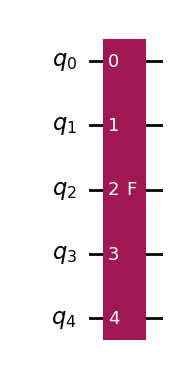

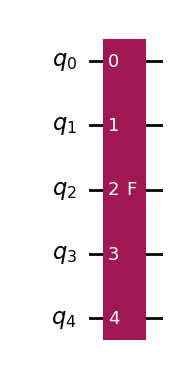

In [8]:
fixed_income._objective.draw(output="mpl")

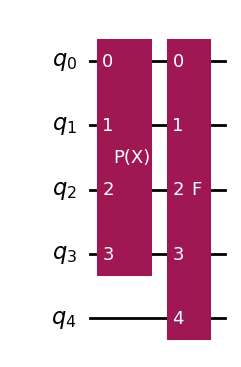

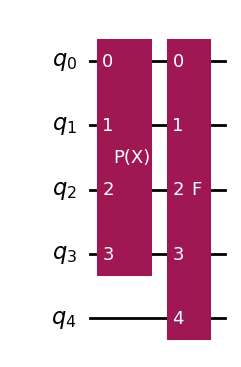

In [9]:
fixed_income_circ = QuantumCircuit(fixed_income._objective.num_qubits)

# load probability distribution
fixed_income_circ.append(u, range(u.num_qubits))

# apply function
fixed_income_circ.append(
    fixed_income._objective, range(fixed_income._objective.num_qubits)
)

fixed_income_circ.draw(output="mpl")

In [10]:
# set target precision and confidence level
epsilon = 0.01
alpha = 0.05

# construct amplitude estimation
problem = fixed_income.to_estimation_problem()

ae = IterativeAmplitudeEstimation(
    epsilon_target=epsilon,
    alpha=alpha,
    sampler=sampler,
)

In [11]:
# Safety guard: ensure sampler is defined before running algorithms
try:
    sampler
except NameError as e:
    raise NameError(
        "sampler is not defined. Run the 'RUN FIRST' cell at the top (Kernel -> Restart & Run All)."
    ) from e

In [12]:
result = ae.estimate(problem)

In [13]:
conf_int = np.array(result.confidence_interval_processed)
print("Exact value:        \t%.4f" % exact_value)
print("Estimated value:    \t%.4f" % (fixed_income.interpret(result)))
print("Confidence interval:\t[%.4f, %.4f]" % tuple(conf_int))

Exact value:        	2.1942
Estimated value:    	2.3349
Confidence interval:	[2.3169, 2.3529]


In [14]:
import importlib.metadata as im

packages = [
    "qiskit",
    "qiskit-aer",
    "qiskit-ibm-runtime",
    "qiskit_algorithms",
    "qiskit_finance",
]

for p in packages:
    try:
        print(f"{p}: {im.version(p)}")
    except im.PackageNotFoundError:
        print(f"{p}: not installed")

qiskit: 2.3.1
qiskit-aer: 0.17.2
qiskit-ibm-runtime: 0.45.1
qiskit_algorithms: 0.4.0
qiskit_finance: 0.4.1
